Цель: проанализировать транзакции интернет-магазина, рассчитать ключевые метрики и визуализировать основные закономерности.

1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Загрузка данных

In [2]:
df = pd.read_csv('../data/E-Commerce Sales Analytics.csv')

3. Осмотр данных

In [3]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 593.2 KB


In [5]:
df.describe(include='all')

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
unique,NaN,5000,NaN,4,4,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,1/1/2022,NaN,Electronics,West,NaN,NaN,NaN,Card,NaN,NaN,NaN
freq,NaN,1,NaN,1777,1289,NaN,NaN,NaN,2270,NaN,NaN,NaN
mean,12500.500000,NaN,1505.701200,NaN,NaN,4.044800,308.418774,0.179984,NaN,6.118800,2.973980,1021.955148
std,1443.520003,NaN,290.836902,NaN,NaN,2.020398,169.259369,0.101404,NaN,3.153264,1.157722,825.584219
min,10001.000000,NaN,1000.000000,NaN,NaN,1.000000,15.150000,0.000000,NaN,1.000000,1.000000,11.210000
25%,11250.750000,NaN,1253.000000,NaN,NaN,2.000000,161.895000,0.090000,NaN,3.000000,2.000000,354.527500
50%,12500.500000,NaN,1510.000000,NaN,NaN,4.000000,309.890000,0.180000,NaN,6.000000,3.000000,796.650000
75%,13750.250000,NaN,1761.000000,NaN,NaN,6.000000,455.557500,0.270000,NaN,9.000000,4.000000,1515.690000


In [6]:
# Количество пропусков в столбцах
print(df.isnull().sum())

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64


In [7]:
# Количество дубликатов
print(df.duplicated().sum())

0


4. Подготовка данных

In [8]:
# Преобразование даты в формат datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Создание новых столбцов
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.dayofweek

# Создание столбца с названиями дней недели и месяцев для более понятных графиков
days = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['day_name'] = df['day_of_week'].map(days)
months = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df['month_name'] = df['month'].map(months)   

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,day_of_week,day_name,month_name
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,5,Sat,Jan
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,6,Sun,Jan
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,0,Mon,Jan
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,1,Tue,Jan
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,2,Wed,Jan


5. Расчет ключевых метрик

In [9]:
# Основные KPI
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
avg_check = round(total_revenue / total_orders,2)
avg_rating = round(df['customer_rating'].mean(),2)

print(f'Общая выручка: {total_revenue}')
print(f'Количество заказов: {total_orders}')
print(f'Средний чек: {avg_check}')
print(f'Средний рейтинг: {avg_rating}')

# Выручка по категориям
categories_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
print(f'Выручка по категориям: {categories_revenue}')

# Выручка по регионам 
regions_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
print(f'Выручка по регионам: {regions_revenue}')

# Средняя оценка зависимости оценки от скидки
discount_rating = round(df.groupby('discount')['customer_rating'].mean(),2)
print(f'Средняя оценка зависимости оценки от скидки: {discount_rating}')

# Выручка по месяцам (сезонность)
monthly_revenue = df.groupby('month')['revenue'].sum()
print(f'Выручка по месяцам: {monthly_revenue}')

Общая выручка: 5109775.74
Количество заказов: 5000
Средний чек: 1021.96
Средний рейтинг: 2.97
Выручка по категориям: product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64
Выручка по регионам: region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64
Средняя оценка зависимости оценки от скидки: discount
0.00    3.16
0.01    3.13
0.02    2.90
0.03    2.90
0.04    2.90
0.05    2.86
0.06    2.88
0.07    3.26
0.08    2.89
0.09    2.90
0.10    2.92
0.11    2.99
0.12    2.95
0.13    2.90
0.14    3.09
0.15    2.93
0.16    2.92
0.17    2.90
0.18    2.99
0.19    2.95
0.20    2.95
0.21    2.99
0.22    3.05
0.23    3.06
0.24    3.05
0.25    2.76
0.26    2.99
0.27    2.97
0.28    3.14
0.29    2.90
0.30    2.86
0.31    2.99
0.32    3.01
0.33    3.12
0.34    2.95
0.35    3.26
Name: customer_rating, dtype: float64
Выручка по месяцам: month
1     42

6. Визуализация ключевых метрик

In [10]:
# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

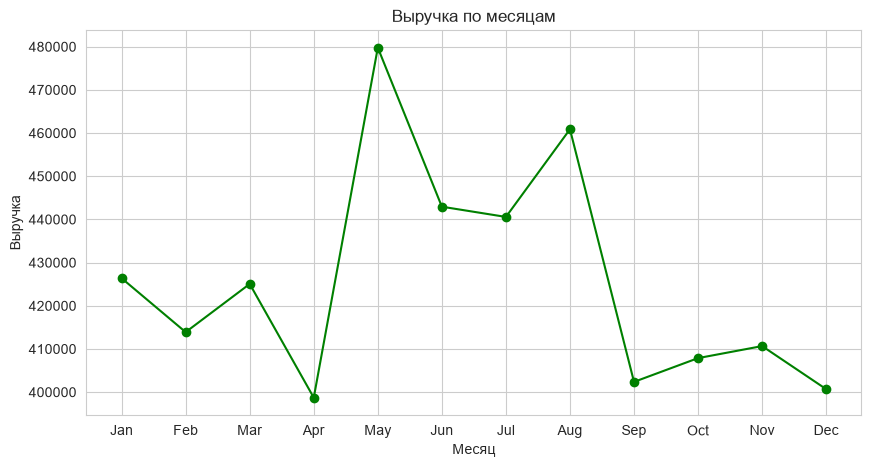

In [11]:
# Выручка по месяцам
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(ticks=range(1, 13), labels=month_order)
plt.show()

Наибольшая выручка наблюдается в мае(479 772), самая низкая в апреле(398 715). Разница в выручке 81 057, что может указывать на сезонный спрос.

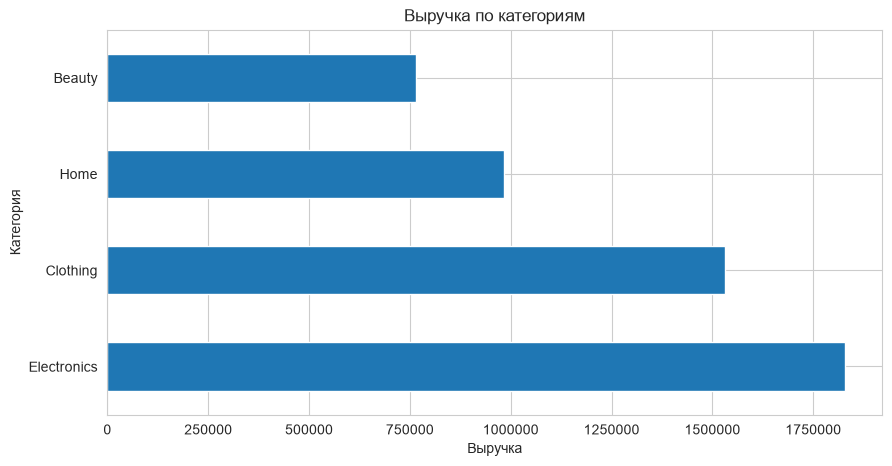

In [12]:
# Выручка по категориям
plt.ticklabel_format(style='plain', axis='x')
categories_revenue.plot(kind='barh')
plt.title('Выручка по категориям')
plt.xlabel('Выручка')
plt.ylabel('Категория')
plt.show()

Категория Electronics приносит наибольшую выручку(1 829 899), а Beauty наименьшую(765 860). 

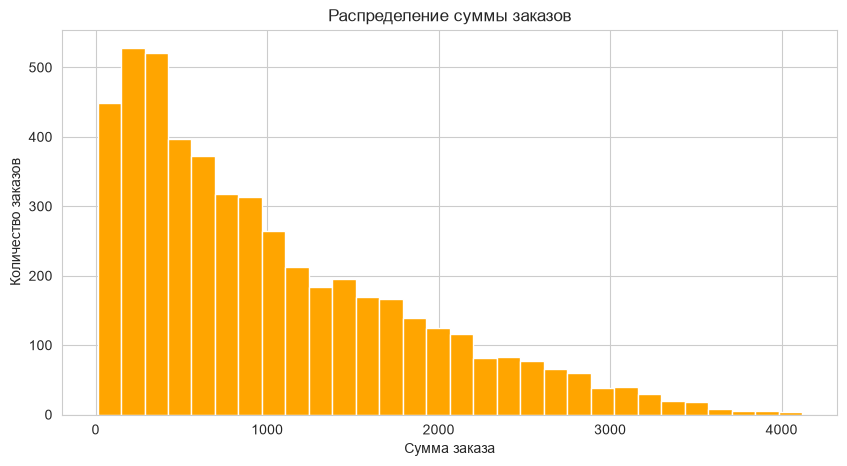

In [13]:
# Распределение суммы заказов
plt.hist(df['revenue'], bins=30, color='orange')
plt.title('Распределение суммы заказов')
plt.xlabel('Сумма заказа')
plt.ylabel('Количество заказов')
plt.show()

Большинство заказов находятся в диапазоне до 1500, крупных заказов очень мало. 

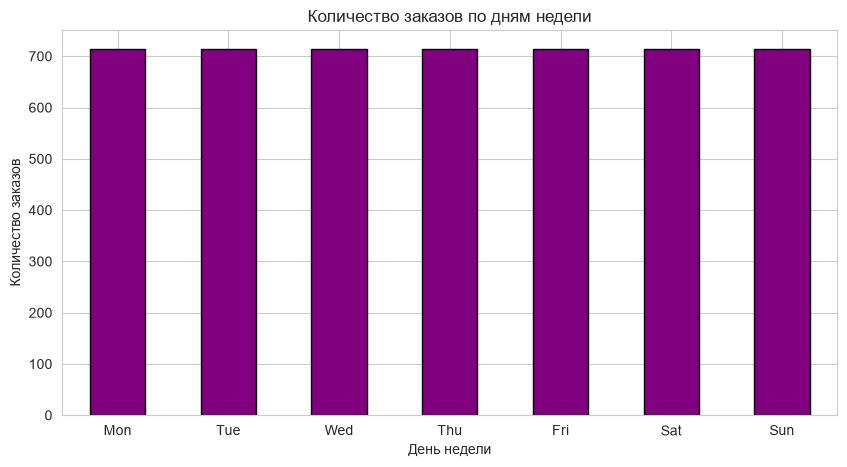

In [14]:
# Количество заказов по дням недели
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
orders_by_day = df.groupby('day_name')['order_id'].count().reindex(day_order)

orders_by_day.plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.title('Количество заказов по дням недели')
plt.xticks(rotation=0)
plt.show()

Количество заказов равномерно распределено по дням недели, значит спрос в выходные не меняется.

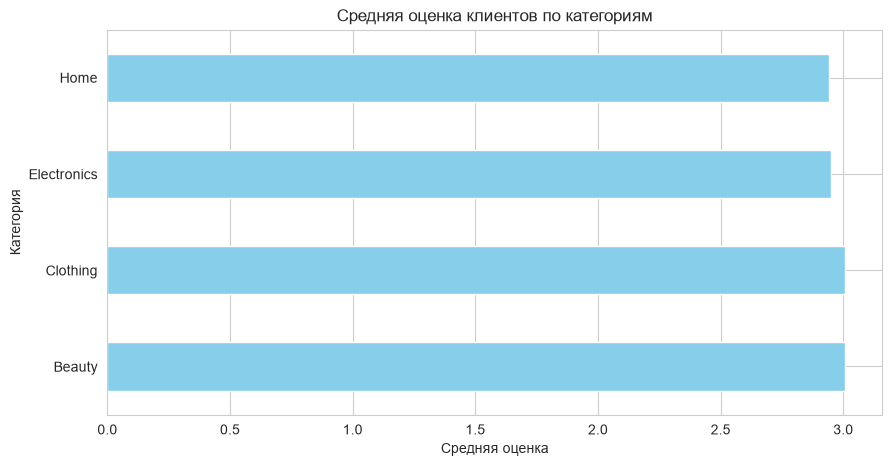

In [15]:
# Средняя оценка по категориям
avg_rating_by_category = df.groupby('product_category')['customer_rating'].mean().sort_values(ascending=False)

avg_rating_by_category.plot(kind='barh', color='skyblue')
plt.xlabel('Средняя оценка')
plt.ylabel('Категория')
plt.title('Средняя оценка клиентов по категориям')
plt.show()

Средняя оценка по категориям примерно равна 3.0.

In [16]:
# Сохранение очищенного датафрейма
df.to_csv('../data/ecommerce_cleaned.csv', index=False)